# Pattern Graph

Yun Gui

## Overview

Reference:
[1] AVITAN L, PUJIC Z, MÖLTER J, 等, 2017. Spontaneous Activity in the Zebrafish Tectum Reorganizes over Development and Is Influenced by Visual Experience: 卷 27[Z/OL]. Current Biology: 2407-2419.e4. [https://www.semanticscholar.org/paper/97a5bc942ae61369182f4b23baa4a1e0cd83e3fe](https://www.semanticscholar.org/paper/97a5bc942ae61369182f4b23baa4a1e0cd83e3fe). DOI:[10.1016/j.cub.2017.06.056](https://doi.org/10.1016/j.cub.2017.06.056).

In [26]:
import os
from brainnetwork import load_data, preprocess_data, preprocess_spike_data

base_dir = "/beegfs_hdd/data/nfs_share/users/guiyun/nishome/Micedata/"
data_path = base_dir + 'M78_1017' # 'M77_1031'

## Data Loading and Preprocessing

load spike data



In [27]:
neuron_data, neuron_pos, start_edges, stimulus_data = load_data(data_path)
segments_spi, labels_spi, neuron_pos_spi = preprocess_spike_data(
        neuron_data,
        neuron_pos,
        start_edges,
        stimulus_data,
        extract_rr=1
    )


原始神经数据形状: (8401, 35499)
使用快速RR筛选算法...
处理 180 个试次, 35499 个神经元
快速RR筛选完成，耗时: 7.27秒


In [28]:
segments_spi.shape, labels_spi.shape, neuron_pos_spi.shape

((180, 710, 50), (180,), (2, 710))

## Reduce dimensionality with UMAP

首先将X转化成长度为N的向量，这里先没有做0-1处理，我觉得我不需要看哪些神经元一起发放【暂时】，这里通过UMAP进行一个简单的降维并查看松散度；

平衡后数据形状: (126, 710)


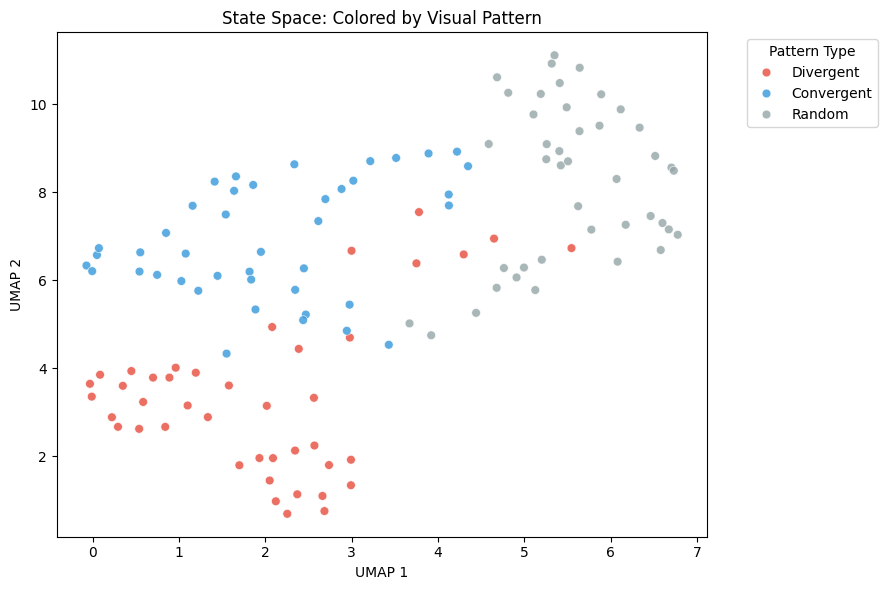

In [29]:
import numpy as np
import umap
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Trial 聚合：计算每个 Trial 的平均活动
# 假设 X_trials 的形状是 (Trial总数, 帧数, 神经元数)
X_trial_averaged = np.mean(segments_spi[:, :, 10:15], axis=2) # 得到 (n_trials, n_neurons)

unique_labels = np.unique(labels_spi)
min_count = min(np.sum(labels_spi == l) for l in unique_labels)

# 2. 平衡数据集
X_balanced_list = []
labels_balanced = []

for label in unique_labels:
    mask = (labels_spi == label)
    X_label = X_trial_averaged[mask]
    
    # 建议：随机采样而非固定取前几个
    indices = np.random.choice(len(X_label), min_count, replace=False)
    X_sampled = X_label[indices]
    
    X_balanced_list.append(X_sampled)
    labels_balanced.extend([label] * min_count)

# 2. 关键修正：将列表转化为单一矩阵 [cite: 1]
X_trial_averaged_balanced = np.vstack(X_balanced_list)
labels_balanced = np.array(labels_balanced)

print(f"平衡后数据形状: {X_trial_averaged_balanced.shape}") # 应为 (min_count * 3, 神经元数)


# 2. 对 Trial 级别的数据进行降维 (UMAP)
reducer = umap.UMAP(n_neighbors=5, min_dist=0.3) 
embedding = reducer.fit_transform(X_trial_averaged_balanced)

# 定义语义映射
label_names = {1: 'Divergent', 2: 'Convergent', 3: 'Random'}
# 这里的颜色方案：Divergent(红), Convergent(蓝), Random(灰/绿)
palette = {1: "#e74c3c", 2: "#3498db", 3: "#95a5a6"}

def plot_pattern_space(embedding, labels, title):
    plt.figure(figsize=(9, 6))
    
    # 转换为语义标签方便绘图
    semantic_labels = [label_names[l] for l in labels]
    
    sns.scatterplot(
        x=embedding[:, 0], 
        y=embedding[:, 1], 
        hue=semantic_labels,
        palette=['#e74c3c', '#3498db', '#95a5a6'], # 对应顺序
        s=40, alpha=0.8, edgecolor='w'
    )
    
    plt.title(title)
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.legend(title="Pattern Type", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# 绘图
plot_pattern_space(embedding, labels_balanced, "State Space: Colored by Visual Pattern")

In [30]:
# embedding 是 UMAP 降维后的 (n_trials, 2) 矩阵
for label in np.unique(labels_balanced):
    mask = (labels_balanced == label)
    cluster_points = embedding[mask]
    
    # 计算质心距离的标准差（衡量簇的半径/松散程度）
    centroid = np.mean(cluster_points, axis=0)
    dist_to_centroid = np.linalg.norm(cluster_points - centroid, axis=1)
    cluster_std = np.std(dist_to_centroid)
    
    print(f"刺激 {label_names[label]} 在状态空间中的松散度 (STD): {cluster_std:.4f}")


刺激 Divergent 在状态空间中的松散度 (STD): 1.0826
刺激 Convergent 在状态空间中的松散度 (STD): 0.6420
刺激 Random 在状态空间中的松散度 (STD): 0.8247


In [31]:
def calculate_participation_ratio(data):
    """
    data: (n_samples, n_features) - 这里的 feature 可以是神经元，也可以是 pattern 的特征
    """
    # 1. 中心化数据
    data_centered = data - np.mean(data, axis=0)
    # 2. 计算协方差矩阵
    cov_matrix = np.cov(data_centered, rowvar=False)
    # 3. 获取特征值
    eigenvalues = np.linalg.eigvalsh(cov_matrix)
    eigenvalues = eigenvalues[eigenvalues > 1e-10] # 去除数值噪声
    
    # 4. 计算 PR
    pr = (np.sum(eigenvalues)**2) / np.sum(eigenvalues**2)
    return pr

# 如果想用更专业的非线性维度估计（推荐）：
# pip install scikit-dimension
import skdim

def calculate_intrinsic_dimension(data):
    # 使用 Two-NN 估算本征维度
    twonn = skdim.id.TwoNN().fit(data)
    return twonn.dimension_

for label in np.unique(labels_balanced):
    mask = (labels_balanced == label)
    cluster_data = X_trial_averaged_balanced[mask]
    
    pr = calculate_participation_ratio(cluster_data)
    id_dim = calculate_intrinsic_dimension(cluster_data)
    
    print(f"刺激 {label_names[label]} 的参与度维数 (PR): {pr:.4f}, 本征维数 (ID): {id_dim:.4f}")


刺激 Divergent 的参与度维数 (PR): 11.4091, 本征维数 (ID): 12.4078
刺激 Convergent 的参与度维数 (PR): 10.0069, 本征维数 (ID): 17.0087
刺激 Random 的参与度维数 (PR): 13.6507, 本征维数 (ID): 19.0608


##  Spectrum cluster

首先先用谱聚类对向量进行聚类，这个过程本质是无监督的，然后计算其模块和真实标签的重合程度

In [32]:
from sklearn.cluster import SpectralClustering

# 1. 准备数据 X (n_trials, n_neurons)
# 2. 定义谱聚类模型
# n_clusters: 聚类数量
# affinity: 'cosine' 或 'nearest_neighbors'（文献中常用 nearest_neighbors 构建图）



spectral_model = SpectralClustering(
    n_clusters=5, 
    affinity='nearest_neighbors', 
    n_neighbors=10, 
    assign_labels='kmeans', 
    random_state=42
)

# 3. 进行聚类
cluster_labels = spectral_model.fit_predict(X_trial_averaged_balanced)


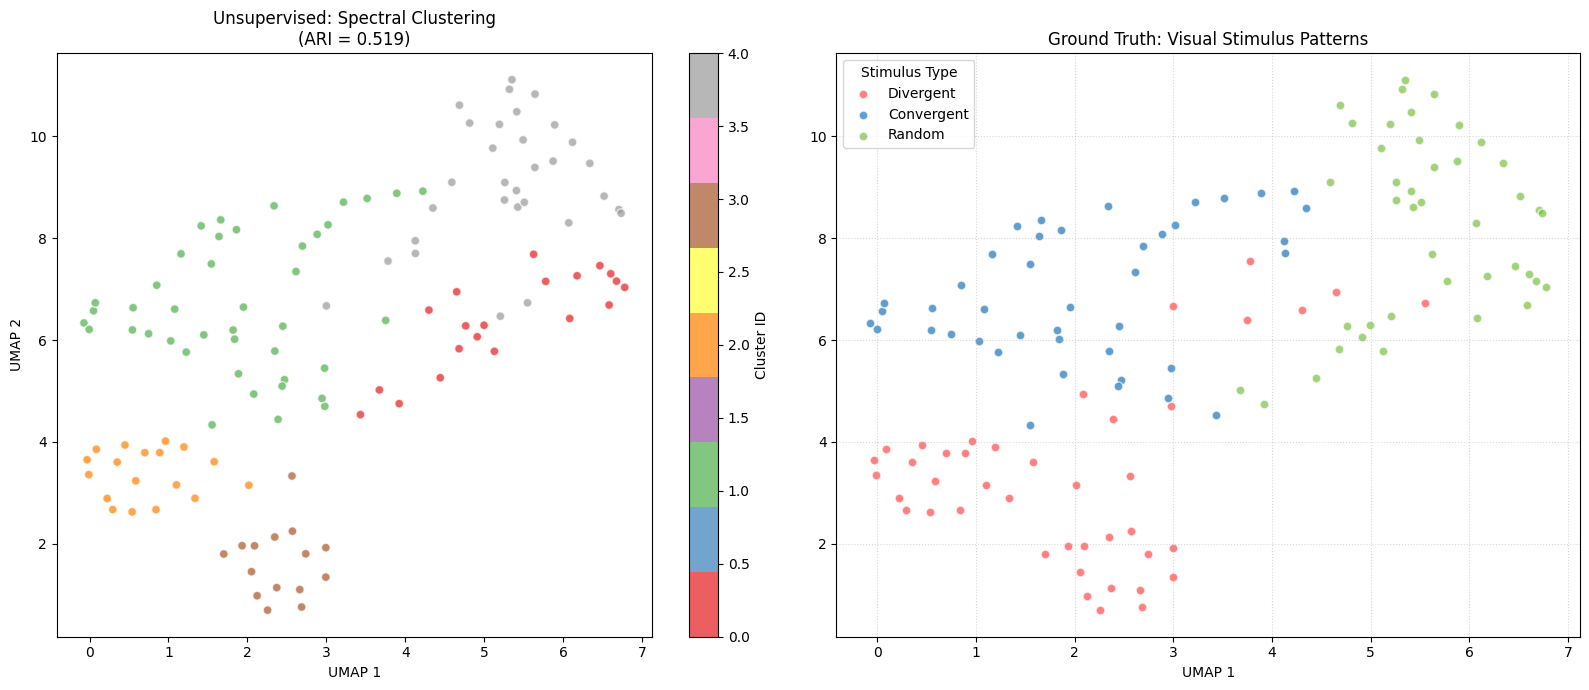

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, adjusted_rand_score

# 0. 准备标签映射
label_names = {1: 'Divergent', 2: 'Convergent', 3: 'Random'}
true_names = [label_names[l] for l in labels_balanced]

# 创建画布：左图展示聚类，右图展示真实标签
fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=100)

# --- 左图：谱聚类结果 ---
scatter1 = axes[0].scatter(embedding[:, 0], embedding[:, 1], 
                            c=cluster_labels, cmap='Set1', s=40, alpha=0.7, edgecolors='w')
axes[0].set_title(f"Unsupervised: Spectral Clustering\n(ARI = {adjusted_rand_score(labels_balanced, cluster_labels):.3f})")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")
fig.colorbar(scatter1, ax=axes[0], label='Cluster ID')

# --- 右图：实验标签（真实分类） ---
# 使用自定义调色板
colors = {'Divergent': '#FF4B4B', 'Convergent': '#1C75BC', 'Random': '#7AC143'}
for name in ['Divergent', 'Convergent', 'Random']:
    mask = np.array(true_names) == name
    axes[1].scatter(embedding[mask, 0], embedding[mask, 1], 
                    label=name, color=colors[name], s=40, alpha=0.7, edgecolors='w')

axes[1].set_title("Ground Truth: Visual Stimulus Patterns")
axes[1].set_xlabel("UMAP 1")
axes[1].legend(title="Stimulus Type")
axes[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

无监督聚类与视觉标签的重合度 (ARI): 0.5187


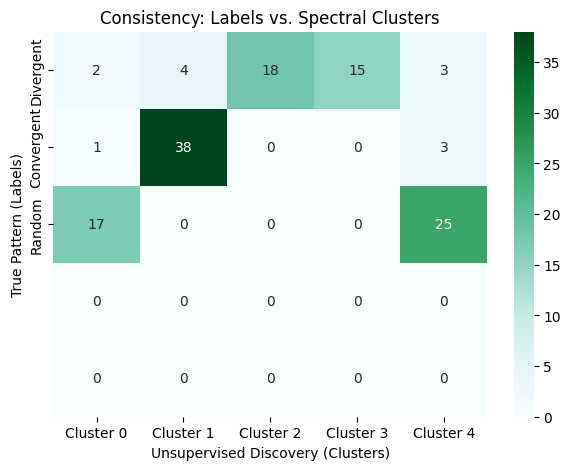

In [34]:
# 1. 计算重合度 (ARI)
ari = adjusted_rand_score(labels_balanced, cluster_labels)
print(f"无监督聚类与视觉标签的重合度 (ARI): {ari:.4f}")

# 2. 绘制混淆矩阵
labels = [i - 1 for i in labels_balanced]  # 将标签调整为从0开始

cm = confusion_matrix(labels, cluster_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='BuGn',
            xticklabels=[f'Cluster {i}' for i in np.unique(cluster_labels)],
            yticklabels=[label_names[i] for i in np.unique(labels_balanced)])
plt.title("Consistency: Labels vs. Spectral Clusters")
plt.ylabel("True Pattern (Labels)")
plt.xlabel("Unsupervised Discovery (Clusters)")
plt.show()

In [35]:
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity

# 1. 构建全局相似性图 (使用余弦相似度)
S = cosine_similarity(X_trial_averaged_balanced)
# 设定阈值（例如相似度前 10% 的连线），将相似度矩阵转为邻接矩阵
threshold = np.percentile(S, 90)
adj = (S > threshold).astype(int)
G_global = nx.from_numpy_array(adj)

# 2. 提取子图并计算特征
label_names = {1: 'Divergent', 2: 'Convergent', 3: 'Random'}
graph_stats = {}

for val, name in label_names.items():
    # 找到属于该标签的节点索引
    nodes = np.where(labels_balanced == val)[0]
    # 提取诱发子图
    sub_g = G_global.subgraph(nodes)
    
    # 计算特征
    graph_stats[name] = {
        "Density": nx.density(sub_g),
        "Avg_Clustering": nx.average_clustering(sub_g),
        "Transitivity": nx.transitivity(sub_g),
        "Local_Efficiency": nx.local_efficiency(sub_g),
        "Global_Efficiency": nx.global_efficiency(sub_g)
    }

# 3. 打印结果对比
import pandas as pd
print(pd.DataFrame(graph_stats).T)

             Density  Avg_Clustering  Transitivity  Local_Efficiency  \
Divergent   0.163763        0.404611      0.518578          0.775737   
Convergent  0.243902        0.488385      0.517766          0.763362   
Random      0.433217        0.735028      0.657107          0.892764   

            Global_Efficiency  
Divergent            0.356568  
Convergent           0.462156  
Random               0.677216  


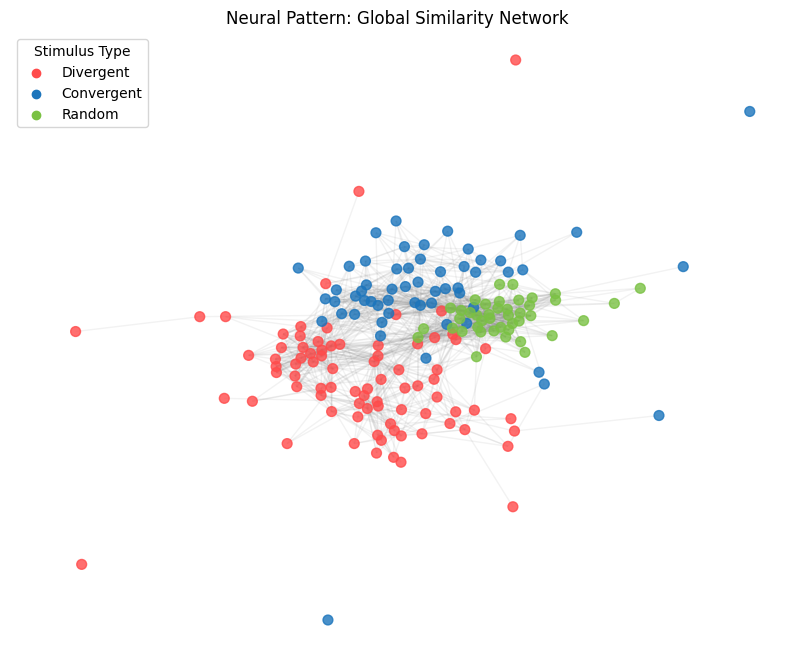

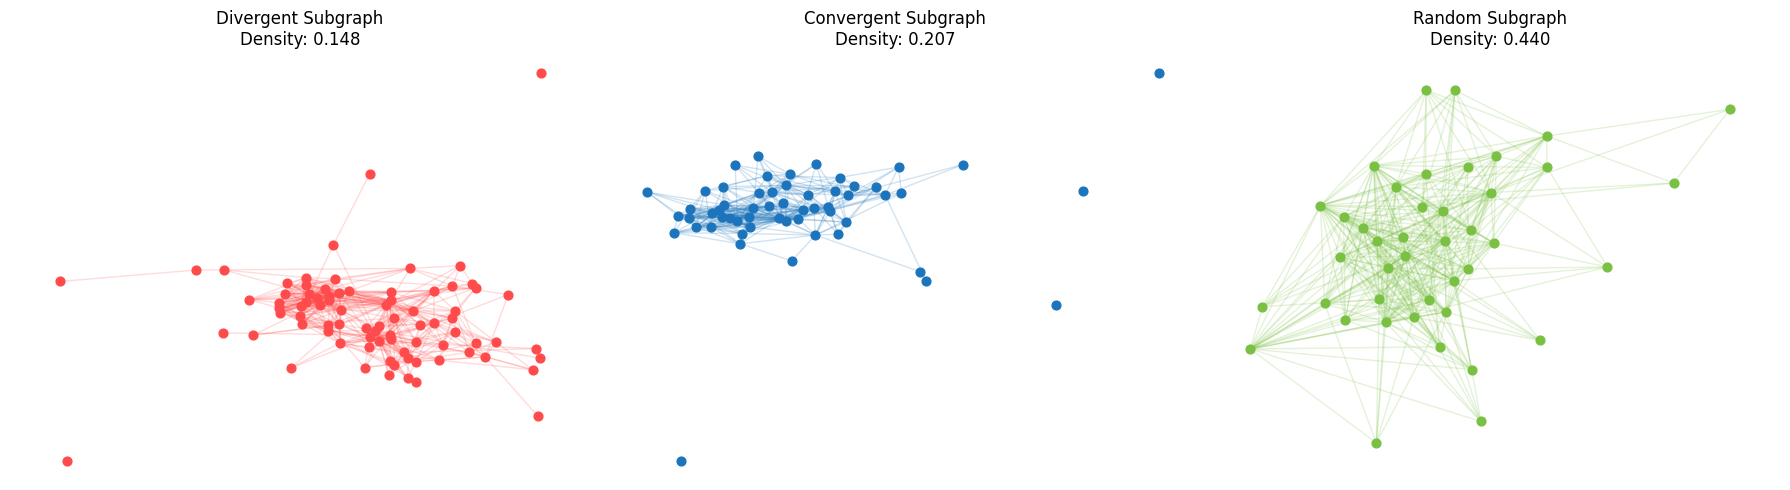

In [36]:
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

def plot_pattern_graphs(X, labels, title_prefix="Neural Pattern"):
    # 1. 计算 Trial 之间的相似度 (余弦相似度)
    S = cosine_similarity(X)
    
    # 2. 设定阈值构建邻接矩阵 (例如保留相似度最高的 10% 的连线)
    threshold = np.percentile(S, 90)
    adj = (S > threshold).astype(int)
    
    # 创建全局图
    G_global = nx.from_numpy_array(adj)
    G_global.remove_edges_from(nx.selfloop_edges(G_global)) # 移除自环
    
    # 定义标签语义和颜色
    label_map = {1: 'Divergent', 2: 'Convergent', 3: 'Random'}
    colors_map = {1: '#FF4B4B', 2: '#1C75BC', 3: '#7AC143'}
    
    # 设置布局 (力导向布局，让相似的点聚在一起)
    pos = nx.spring_layout(G_global, k=0.2, seed=42)
    
    # --- 绘图 1: 全局连接图 ---
    plt.figure(figsize=(10, 8))
    node_colors = [colors_map.get(l, 'gray') for l in labels]
    
    nx.draw_networkx_nodes(G_global, pos, node_size=50, node_color=node_colors, alpha=0.8)
    nx.draw_networkx_edges(G_global, pos, alpha=0.1, edge_color='gray')
    
    # 添加图例
    for l, name in label_map.items():
        plt.scatter([], [], c=colors_map[l], label=name)
    plt.legend(title="Stimulus Type")
    plt.title(f"{title_prefix}: Global Similarity Network")
    plt.axis('off')
    plt.show()

    # --- 绘图 2: 三种模式子图对比 ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, (l, name) in enumerate(label_map.items()):
        # 提取子图
        nodes = np.where(labels == l)[0]
        sub_g = G_global.subgraph(nodes)
        
        # 子图布局
        sub_pos = {n: pos[n] for n in nodes}
        nx.draw_networkx_nodes(sub_g, sub_pos, ax=axes[i], node_size=40, node_color=colors_map[l])
        nx.draw_networkx_edges(sub_g, sub_pos, ax=axes[i], alpha=0.2, edge_color=colors_map[l])
        
        # 计算该子图的密度
        density = nx.density(sub_g)
        axes[i].set_title(f"{name} Subgraph\nDensity: {density:.3f}")
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# 调用函数 (使用您之前的变量)
plot_pattern_graphs(X_trial_averaged, labels_spi)